# Explore here

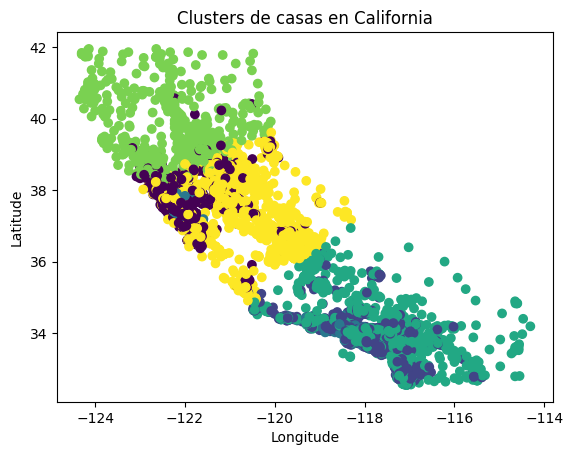

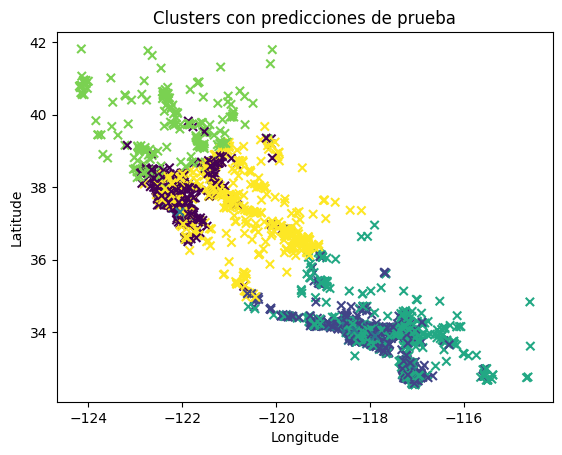

Exactitud del modelo supervisado: 0.9949
Matriz de confusión:
 [[ 556    0    0    0    1    0]
 [   0  895    0    1    0    1]
 [   1    2  113    0    0    0]
 [   0    2    0 1394    0    1]
 [   0    0    0    0  243    3]
 [   6    0    0    0    3  906]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       557
           1       1.00      1.00      1.00       897
           2       1.00      0.97      0.99       116
           3       1.00      1.00      1.00      1397
           4       0.98      0.99      0.99       246
           5       0.99      0.99      0.99       915

    accuracy                           0.99      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       0.99      0.99      0.99      4128



['scaler.pkl']

In [1]:
# Your code here
 
import pandas as pd  # Para manejar el conjunto de datos
import numpy as np  # Para operaciones matemáticas
import matplotlib.pyplot as plt  # Para graficar resultados
from sklearn.model_selection import train_test_split  # Para dividir los datos en entrenamiento y prueba
from sklearn.cluster import KMeans  # Para implementar K-Means
from sklearn.preprocessing import StandardScaler  # Para escalar los datos
from sklearn.ensemble import RandomForestClassifier  # Para clasificación supervisada
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Para evaluación de modelos
import joblib  # Para almacenar los modelos

# Paso 1: Carga del conjunto de datos
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv"
df = pd.read_csv(url)
df = df[["Latitude", "Longitude", "MedInc"]]  # Selección de columnas relevantes
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)  # División en entrenamiento y prueba

# Paso 2: Construcción de K-Means
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Escalamos los datos de entrenamiento
kmeans = KMeans(n_clusters=6, random_state=42)
X_train["cluster"] = kmeans.fit_predict(X_train_scaled)  # Aplicamos K-Means y guardamos los clusters
plt.scatter(X_train["Longitude"], X_train["Latitude"], c=X_train["cluster"], cmap="viridis")  # Graficamos los clusters
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Clusters de casas en California")
plt.show()

# Paso 3: Predicción con el conjunto de prueba
X_test_scaled = scaler.transform(X_test)  # Escalamos los datos de prueba
X_test["cluster"] = kmeans.predict(X_test_scaled)  # Asignamos los clusters predichos
plt.scatter(X_test["Longitude"], X_test["Latitude"], c=X_test["cluster"], cmap="viridis", marker="x")  # Añadimos puntos de prueba al gráfico
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Clusters con predicciones de prueba")
plt.show()

# Paso 4: Entrenamiento de un modelo de clasificación supervisada
clf = RandomForestClassifier(n_estimators=100, random_state=42)  # Creamos un modelo de clasificación
clf.fit(X_train_scaled, X_train["cluster"])  # Entrenamos el modelo con los clusters obtenidos
y_pred = clf.predict(X_test_scaled)  # Realizamos predicciones con el modelo supervisado
print(f"Exactitud del modelo supervisado: {accuracy_score(X_test['cluster'], y_pred):.4f}")  # Evaluación del modelo
print("Matriz de confusión:\n", confusion_matrix(X_test["cluster"], y_pred))  # Matriz de confusión
print("Reporte de clasificación:\n", classification_report(X_test["cluster"], y_pred))  # Reporte de clasificación

# Paso 5: Guardado de los modelos
joblib.dump(kmeans, "kmeans_model.pkl")  # Guardamos el modelo K-Means
joblib.dump(clf, "classification_model.pkl")  # Guardamos el modelo de clasificación
joblib.dump(scaler, "scaler.pkl")  # Guardamos el escalador para futuras predicciones